# 05. cuPF GPU: Jacobian fill과 sparse solve의 위치 바꾸기

GPU로 옮긴다고 Newton-Raphson이 다른 문제가 되는 것은 아니다. 여전히 `mismatch -> Jacobian -> J dx = -F -> update`다. 달라지는 것은 비용이 어디서 발생하고 어떤 라이브러리/커널이 담당하는가다.

- `cuda_cudss.cpp`: cuDSS handle, sparse matrix descriptor, factorization/solve 흐름을 Newton pipeline에 연결한다.
- CUDA Jacobian fill: `Edge`, `EdgeAtomic`, `VertexWarp` 중 하나로 Jacobian 값을 채운다.
- custom solver: 범용 cuDSS와 비교하기 위한 연구용 linear solve path다.

edge/vertex 차이가 작게 보이면 그 자체가 정보다. Jacobian fill보다 sparse factorization/solve가 전체 시간을 지배하면 kernel 차이는 solve time에 작게 나타난다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_BENCHMARKS = True
REPEATS = 1
WARMUP = 0


In [2]:
display(pd.DataFrame([
    {'variant': 'cupf-cpu-klu', 'role': 'CPU reference after KLU/native Jacobian optimization'},
    {'variant': 'cupf-fp64-cudss', 'role': 'GPU Jacobian Edge + cuDSS sparse solve'},
    {'variant': 'cupf-fp64-cudss-edge-atomic', 'role': 'legacy edge fill with atomic diagonal accumulation'},
    {'variant': 'cupf-fp64-cudss-vertex-warp', 'role': 'warp-per-bus style vertex fill'},
]))


,variant,role
0,cupf-cpu-klu,CPU reference after KLU/native Jacobian optimization
1,cupf-fp64-cudss,GPU Jacobian Edge + cuDSS sparse solve
2,cupf-fp64-cudss-edge-atomic,legacy edge fill with atomic diagonal accumulation
3,cupf-fp64-cudss-vertex-warp,warp-per-bus style vertex fill


CPU와 GPU build를 모두 준비한다. CPU variant를 같이 넣는 이유는 GPU 결과를 고립된 숫자로 보지 않고, 같은 Newton step의 CPU 기준과 비교하기 위해서다.


In [3]:
cpu_build = tu.build_eval('cpu', jobs=2, timeout=2400)
gpu_build = tu.build_eval('gpu', jobs=2, timeout=3600)
print(tu.command_summary(cpu_build, tail_lines=12))
print(tu.command_summary(gpu_build, tail_lines=12))


$ bash benchmark/scripts/build_eval.bash cpu --jobs 2
[OK] elapsed=0.2s
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval] build _cupf + cupf_cpp_evaluate (-j 2)
Consolidate compiler generated dependencies of target cupf
[ 87%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 82%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-cpu
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-cpu/_cupf.cpython-310-x86_64-linux-gnu.so
$ bash benchmark/scripts/build_eval.bash gpu --jobs 2
[OK] elapsed=0.3s
-- Build files have been written to: /workspace/gpu-powerflow-master/cuPF/build/eval-gpu
[build_eval] build _cupf + cupf_cpp_ev

$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-gpu-20260601-134004 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-cpu-klu-pybind cupf-fp64-cudss-pybind cupf-fp64-cudss-edge-atomic-pybind cupf-fp64-cudss-vertex-warp-pybind
[OK] elapsed=14.6s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-gpu-20260601-134004 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-cpu-klu-pybind cupf-fp64-cudss-edge-atomic-pybind cupf-fp64-cudss-pybind cupf-fp64-cudss-vertex-warp-pybind
[cupf-cpu-klu-pybind][OK] case6468rte repeat=0 init_ms=7.816 solve_ms=12.086 iters=4 resid=1.341e-11
[cupf-cpu-klu-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/

,variant,linear_solver,jacobian,initialize_ms,solve_ms,worst_residual,entrypoint
0,cupf-cpu-klu-pybind,klu,native,7.816010,12.086254,1.340572e-11,pybind
1,cupf-fp64-cudss-edge-atomic-pybind,cudss,edge_atomic,89.315142,21.571223,1.704375e-11,pybind
2,cupf-fp64-cudss-pybind,cudss,edge,83.843025,21.791396,8.130385e-12,pybind
3,cupf-fp64-cudss-vertex-warp-pybind,cudss,vertex_warp,83.761493,22.272758,1.036643e-11,pybind


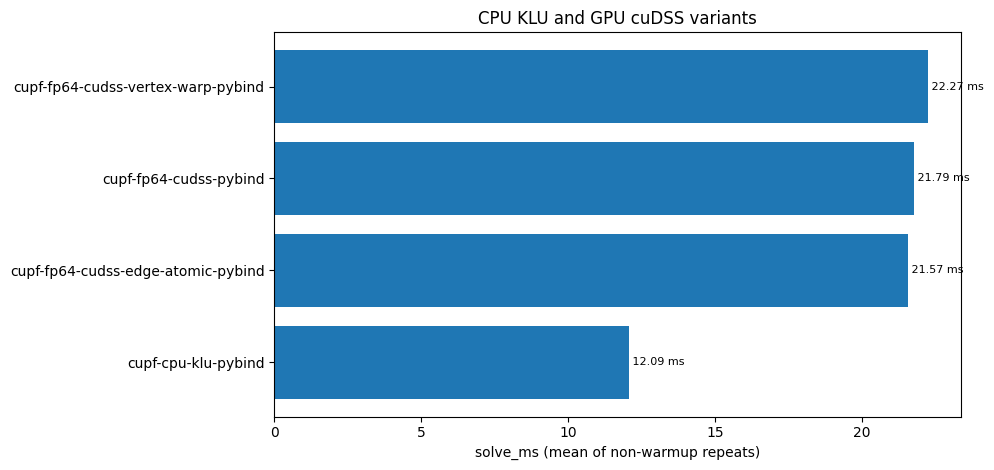

In [4]:
variants = [
    'cupf-cpu-klu-pybind',
    'cupf-fp64-cudss-pybind',
    'cupf-fp64-cudss-edge-atomic-pybind',
    'cupf-fp64-cudss-vertex-warp-pybind',
]
if RUN_BENCHMARKS:
    run_dir, command = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-gpu'),
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=3600,
    )
    print(tu.command_summary(command, tail_lines=18))
else:
    run_dir = tu.tutorial_output_root()

summary = tu.benchmark_result_table(run_dir)
display(summary[['variant', 'linear_solver', 'jacobian', 'initialize_ms', 'solve_ms', 'worst_residual', 'entrypoint']])
fig, ax = plt.subplots(figsize=(10, 4.8))
tu.plot_variant_timing(summary, ax, 'CPU KLU and GPU cuDSS variants')
plt.tight_layout()


custom solver는 본문 흐름의 결론이 아니라 연구용 비교점이다. 그래서 별도로 실행한다. 성공하면 cuDSS와 비교할 수 있고, 실패하면 custom path가 아직 build/runtime dependency를 더 요구한다는 신호로 기록한다.


In [5]:
custom_build = tu.build_eval('gpu-custom', jobs=2, timeout=3600)
print(tu.command_summary(custom_build, tail_lines=12))
if custom_build.ok and RUN_BENCHMARKS:
    custom_dir, custom_command = tu.run_tutorial_benchmark(
        variants=['cupf-fp64-custom-pybind'],
        run_name=tu.timestamp_run_name('tutorial-gpu-custom'),
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=3600,
    )
    print(tu.command_summary(custom_command, tail_lines=18))
    display(tu.benchmark_result_table(custom_dir))
else:
    print('custom solver comparison is unavailable in this environment/build.')


$ bash benchmark/scripts/build_eval.bash gpu-custom --jobs 2
[OK] elapsed=0.4s
[ 25%] Built target custom_linear_solver_ops
Consolidate compiler generated dependencies of target cupf
[ 92%] Built target cupf
Consolidate compiler generated dependencies of target _cupf
[100%] Built target _cupf
[ 25%] Built target custom_linear_solver_ops
[ 90%] Built target cupf
Consolidate compiler generated dependencies of target cupf_cpp_evaluate
[100%] Built target cupf_cpp_evaluate
[build_eval] done. artifacts under /workspace/gpu-powerflow-master/cuPF/build/eval-gpu-custom
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-gpu-custom/tests/cupf_cpp_evaluate
[build_eval]   /workspace/gpu-powerflow-master/cuPF/build/eval-gpu-custom/_cupf.cpython-310-x86_64-linux-gnu.so


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-gpu-custom-20260601-134019 --cases case6468rte --repeats 1 --warmup 0 --variants cupf-fp64-custom-pybind
[OK] elapsed=4.1s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_cupf_pybind --dataset-root /datasets/matpower --run-name tutorial-gpu-custom-20260601-134019 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte --variants cupf-fp64-custom-pybind
[cupf-fp64-custom-pybind][OK] case6468rte repeat=0 init_ms=20.353 solve_ms=6.402 iters=4 resid=1.292e-11
[cupf-fp64-custom-pybind] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-gpu-custom-20260601-134019/cupf-fp64-custom-pybind/runs.csv
[aggregate] 1 rows -> /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-gpu

,variant,cases,successful_rows,converged_rows,initialize_ms,solve_ms,worst_residual,linear_solver,jacobian,entrypoint
0,cupf-fp64-custom-pybind,1,1,1,20.35312,6.401759,1.292221e-11,custom,edge,pybind


GPU path의 결론은 “GPU가 항상 압도적으로 빠르다”가 아니다. 전력조류 Newton solve에서 가장 비싼 구간이 sparse direct solve라면, Jacobian fill kernel을 바꾸는 실험은 전체 solve time에 제한적으로만 보일 수 있다. 이 관찰이 다음 단계의 custom solver, multi-GPU, mixed precision 연구로 이어진다.
